## Results for mixture toy example

In [ ]:
import numpy as np
import pandas as pd
import glob
import pickle
import os
import sys

from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.cm as cm
import seaborn as sns


parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])
OUTDIR = os.path.join(parent_dir,'mixture_outputs_new')
PATTERN = "mixture_outputs_*.npz"
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))

from FastKernCP.utils import *

In [2]:
BASE_SEED = 214
NCLUSTERS = 3
NTRIALS = 50
NSAMPLE = 1000
NFEATURES = 1000
NMIXTURES = 3
test_prop = 0.1
calib_prop = 0.3
alpha = 0.1
NBINS = 10

In [3]:
with open(os.path.join(OUTDIR,'all_list.pkl'), 'rb') as f:
    all_dist = pickle.load(f)
calib = all_dist[0]

kde = gaussian_kde(calib.T, bw_method='scott')
density = kde(calib.T)
n_clusters = NBINS
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
kmeans.fit(calib, sample_weight=density)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


## Plot calibration and test densities

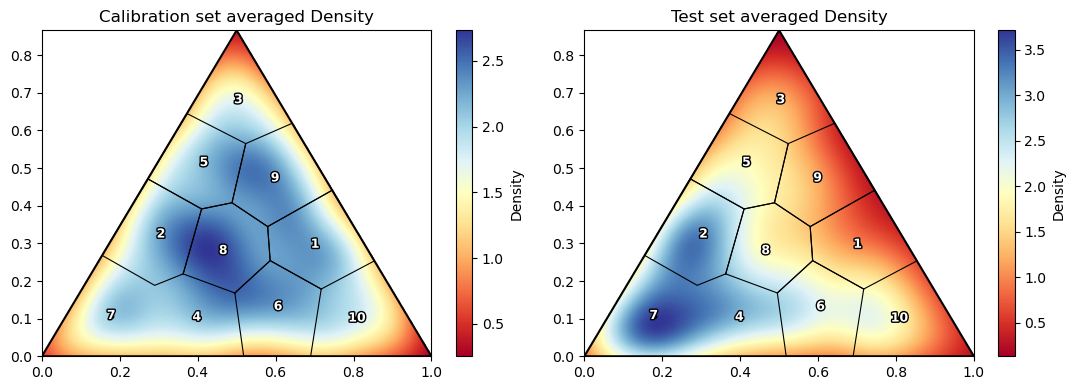

In [4]:
def barycentric_to_cartesian(p):
    """ Map (p1, p2, p3) probability vector to 2D Cartesian coordinates in simplex """
    x = 0.5 * (2*p[:,1] + p[:,2]) / (p[:,0] + p[:,1] + p[:,2])
    y = (np.sqrt(3)/2) * p[:,2] / (p[:,0] + p[:,1] + p[:,2])
    return np.column_stack((x, y))

grid_size = 300
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, np.sqrt(3)/2, grid_size)
X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()])
mask = (Y.flatten() <= (-np.sqrt(3)*X.flatten() + np.sqrt(3))) & (Y.flatten() <= (np.sqrt(3)*X.flatten()))

centroids = kmeans.cluster_centers_
vor = Voronoi(centroids)

# --- Plot ---
fig, axs = plt.subplots(1,2, figsize=(11, 4))
cmap = plt.cm.RdYlBu
norm = mcolors.Normalize(vmin=0, vmax=50)

titles = ["Calibration set averaged Density", "Test set averaged Density"]
for l, arr in enumerate(all_dist):
    kde = gaussian_kde(arr.T, bw_method='scott')
    density = kde(positions)
    density = density.reshape(grid_size, grid_size)
    density = np.where(mask.reshape(grid_size, grid_size), density, np.nan)  # mask outside

    triangle = np.array([[0,0], [1,0], [0.5,np.sqrt(3)/2], [0,0]])
    
    ax = axs[l]
    heatmap = ax.imshow(
                    density,
                    origin='lower',
                    extent=[0, 1, 0, np.sqrt(3)/2],
                    cmap=cmap,
                    aspect='auto'
                )
    
    simplex_polygon = Polygon(triangle[:3])
    
    ax.plot(triangle[:,0], triangle[:,1], color='black')

    for i, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        try:
            poly = Polygon([vor.vertices[j] for j in region])
            clipped = poly.intersection(simplex_polygon)
            if clipped.is_empty:
                continue
            if clipped.geom_type == "Polygon":
                x, y = clipped.exterior.xy
                ax.plot(x, y, color='black', lw=0.8)
            elif clipped.geom_type == "MultiPolygon":
                for subpoly in clipped:
                    x, y = subpoly.exterior.xy
                    ax.plot(x, y, color='black', lw=0.8)
        except:
            continue

    ax.scatter(centroids[:, 0], centroids[:, 1], s=10, c='black')

    for j, (x, y) in enumerate(centroids):
        ax.text(
            x, y, str(j+1),
            ha='center', va='center',
            fontsize=9, weight='bold', color='white',
            zorder=4,
            path_effects=[pe.withStroke(linewidth=2, foreground='black')]
        )

    plt.colorbar(heatmap, ax=ax, label="Density")
    axs[l].set_xlim(0, 1)
    ax.set_ylim(0, np.sqrt(3)/2)
    ax.set_title(titles[l])
plt.tight_layout()
plt.show()

## Plot coverage for NN

In [5]:
methods_to_include = [
    ("SpeedCP",  "speedcp_covers",    "speedcp_cutoffs",    "speedcp_time"),
    ("CondCP",    "condconf_covers",    "condconf_cutoffs",    "condconf_time"),
    ("SplitCP",    "scp_covers",         "scp_cutoffs",         "scp_time"),
    ("PCP",         "pcp_covers",         "pcp_cutoffs",         "pcp_time"),
    ("RLCP",        "rlcp_covers",        "rlcp_cutoffs",        "rlcp_time"),
]

method_names = [m[0] for m in methods_to_include]

W_all = []
covers_list = {method: [] for method in method_names}
cutoffs_list = {method: [] for method in method_names}

coverage_df = pd.DataFrame()

for f in files:
    d = np.load(f, allow_pickle=True)

    seed = int(d["seed"])
    if "predictor" in d.files:
        predictor = str(d["predictor"])
    else:
        predictor = "linreg"

    if "n" in d.files:
        n_val = int(d["n"])
    else:
        n_val = NSAMPLE

    if "W_source" in d.files:
        W_source = str(d["W_source"])
    else:
        W_source = "est"
    
    if predictor != "nn":
        continue

    W_test = d['W_test']
    W_all.append(W_test)

    # Predict bins
    W_cart = barycentric_to_cartesian(W_test)
    bin_membership = kmeans.predict(W_cart)
    W_with_bins = np.hstack([W_test, bin_membership[:, None]])

    # Get topics
    topics = np.argmax(W_test, axis=1)

    for method_name, cov_key, cutoff_key, time_key in methods_to_include:
        cutoffs = d[cutoff_key]
        covers = d[cov_key]

        # SplitCP cutoffs are scalar; broadcast to length n_test
        if method_name == 'SplitCP':
            cutoffs = np.array([cutoffs] * len(W_test))

        covers_list[method_name].append(covers)
        cutoffs_list[method_name].append(cutoffs)
        runtime = float(d[time_key])

        # ---- Marginal coverage ----
        miscov = 1 - np.mean(covers)
        mean_cutoff = np.mean(cutoffs)

        coverage_df = pd.concat([
            coverage_df,
            pd.DataFrame([{
                "seed": seed,
                "coverage": miscov,
                "shift_type": "Marginal",
                "time": runtime,
                "cutoff": mean_cutoff,
                "method": method_name,
                "predictor": predictor,
                "n": n_val,
                "W_source": W_source,
            }])
        ], ignore_index=True)

        # ---- Topic clusters (Cluster1..K) ----
        for k in range(NCLUSTERS):
            idx = np.where(topics == k)[0]
            if len(idx) == 0:
                continue
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": f'Cluster{k+1}',
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name,
                    "predictor": predictor,
                    "n": n_val,
                    "W_source": W_source,
                }])
            ], ignore_index=True)

        # ---- Voronoi bin clusters (Bin1..NBINS) ----
        for k in range(NBINS):
            idx = np.where(W_with_bins[:, 3] == k)[0]
            if len(idx) == 0:
                continue
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": f'Bin{k+1}',
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name,
                    "predictor": predictor,
                    "n": n_val,
                    "W_source": W_source,
                }])
            ], ignore_index=True)

In [6]:
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

In [7]:
marg = coverage_df[coverage_df["shift_type"] == "Marginal"].copy()

marg_summary_all = (
    marg.groupby(["predictor", "n", "W_source", "method"], as_index=False)
        .agg(
            coverage_mean=("coverage", "mean"),
            coverage_sd=("coverage", "std"),
            cutoff_mean=("cutoff", "mean"),
            cutoff_sd=("cutoff", "std"),
            time_mean=("time", "mean"),
            time_sd=("time", "std"),
        )
)

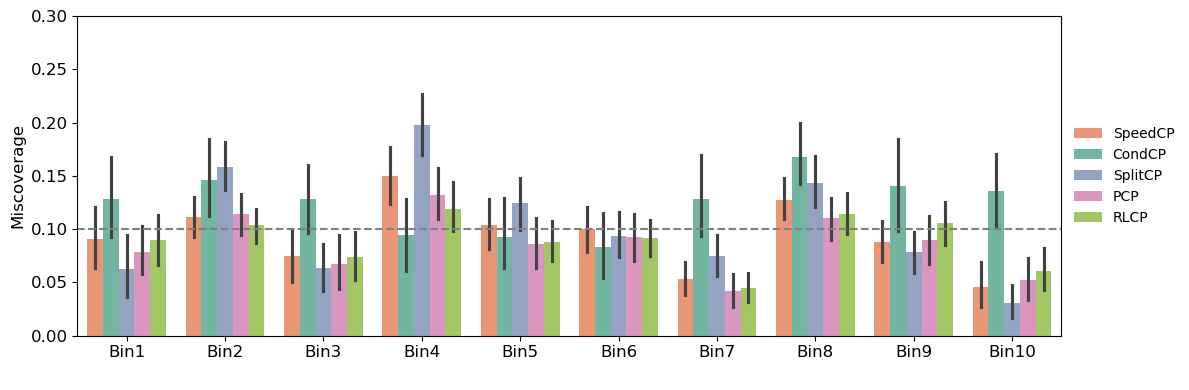

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)
coverage_df_nn = coverage_df[coverage_df['predictor'] == "nn"]

# Create boxplot
sns.barplot(data=coverage_df_nn[coverage_df_nn['shift_type'].str.startswith('Bin')], 
            x="shift_type", y="coverage", hue="method", 
            palette=palette, ax=ax)
legend = sns.move_legend(
    ax, "center left",
    bbox_to_anchor=(1, 0.5), ncol=1, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)
ax.set_ylim(0, 0.3)
ax.axhline(0.1, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Miscoverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

In [9]:
PREDICTORS = ["linreg", "nn"]
N_FIXED = 2000
W_FIXED = "est"

marg_summary_pred = marg_summary_all[
    (marg_summary_all["n"] == N_FIXED) &
    (marg_summary_all["W_source"] == W_FIXED) &
    (marg_summary_all["predictor"].isin(PREDICTORS))
].copy()

def get_matrices_for_method_predictors(method_name, df, predictors):
    sub = df[df["method"] == method_name].copy()

    cov_mat  = np.full((1, len(predictors)), "-", dtype=object)
    size_mat = np.full((1, len(predictors)), "-", dtype=object)
    time_mat = np.full((1, len(predictors)), "-", dtype=object)

    for j, pred in enumerate(predictors):
        row = sub[sub["predictor"] == pred]
        if not row.empty:
            # coverage
            cm = row["coverage_mean"].iloc[0]
            cs = row["coverage_sd"].iloc[0]
            cov_mat[0, j] = f"{cm:.3f} ({cs:.3f})"

            # prediction size
            m = row["cutoff_mean"].iloc[0]
            s = row["cutoff_sd"].iloc[0]
            size_mat[0, j] = f"{m:.3f} ({s:.3f})"

            # time
            tm = row["time_mean"].iloc[0]
            ts = row["time_sd"].iloc[0]
            time_mat[0, j] = f"{tm:.3f} ({ts:.3f})"

    return cov_mat, size_mat, time_mat

methods = sorted(marg_summary_pred["method"].unique())

for method in methods:
    cov_mat, size_mat, time_mat = get_matrices_for_method_predictors(
        method, marg_summary_pred, PREDICTORS
    )

    print(f"\n=== {method} (n = {N_FIXED}, W_source = {W_FIXED}) ===")
    header = [" " * 10] + PREDICTORS
    print("  ".join(f"{h:>12}" for h in header))

    # Row 1: marginal coverage
    cells_cov = ["cov"] + list(cov_mat[0])
    print("  ".join(f"{c:>12}" for c in cells_cov))

    # Row 2: prediction size
    cells_size = ["size"] + list(size_mat[0])
    print("  ".join(f"{c:>12}" for c in cells_size))

    # Row 3: runtime
    cells_time = ["time"] + list(time_mat[0])
    print("  ".join(f"{c:>12}" for c in cells_time))


=== CondCP (n = 2000, W_source = est) ===
                    linreg            nn
         cov             -  0.124 (0.052)
        size             -  2.126 (0.317)
        time             -  1185.696 (69.414)

=== PCP (n = 2000, W_source = est) ===
                    linreg            nn
         cov             -  0.088 (0.029)
        size             -  0.910 (0.130)
        time             -  19.950 (2.661)

=== RLCP (n = 2000, W_source = est) ===
                    linreg            nn
         cov             -  0.089 (0.020)
        size             -  0.864 (0.079)
        time             -  0.834 (0.062)

=== SpeedCP (n = 2000, W_source = est) ===
                    linreg            nn
         cov             -  0.098 (0.026)
        size             -  0.804 (0.067)
        time             -  36.968 (5.815)

=== SplitCP (n = 2000, W_source = est) ===
                    linreg            nn
         cov             -  0.114 (0.027)
        size             -  0.7

In [ ]:
# Which configuration to visualize?
N_FIXED = 2000
W_FIXED = "est"        # or "true"
PREDICTORS = ["linreg", "nn"]

resid_by_pred = {p: [] for p in PREDICTORS}

for f in files:
    d = np.load(f, allow_pickle=True)
    
    # safely get metadata
    predictor = str(d["predictor"]) if "predictor" in d.files else "linreg"
    n_val = int(d["n"]) if "n" in d.files else None
    W_source = str(d["W_source"]) if "W_source" in d.files else "est"

    if predictor not in PREDICTORS:
        continue
    if n_val != N_FIXED:
        continue
    if W_source != W_FIXED:
        continue

    resid_test = d["resid_test"]  # these are |y_hat - y| in your pipeline
    resid_by_pred[predictor].append(resid_test)

# concatenate across seeds
for pred in PREDICTORS:
    if resid_by_pred[pred]:
        resid_by_pred[pred] = np.concatenate(resid_by_pred[pred])
    else:
        resid_by_pred[pred] = np.array([])

linreg num residuals: 5000
rf num residuals: 5000
nn num residuals: 5000


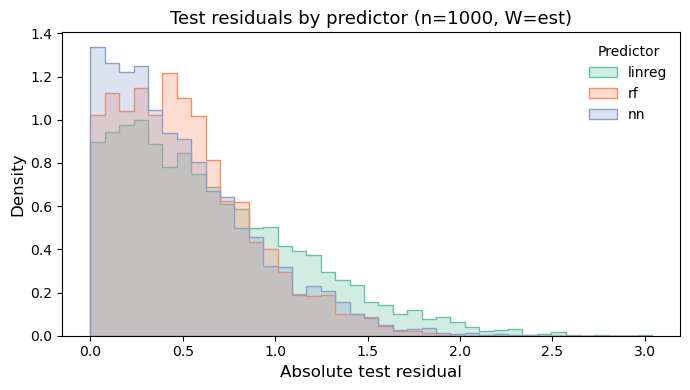

In [23]:
# check if we have data
for pred in PREDICTORS:
    print(pred, "num residuals:", len(resid_by_pred[pred]))

fig, ax = plt.subplots(figsize=(7, 4))

colors = sns.color_palette("Set2", n_colors=len(PREDICTORS))

# common binning across all predictors
all_resid = np.concatenate([v for v in resid_by_pred.values() if len(v) > 0])
bins = np.linspace(all_resid.min(), all_resid.max(), 40)

for color, pred in zip(colors, PREDICTORS):
    r = resid_by_pred[pred]
    if len(r) == 0:
        continue
    sns.histplot(
        r,
        bins=bins,
        stat="density",
        kde=False,
        element="step",
        fill=True,
        alpha=0.3,
        label=pred,
        ax=ax,
        color=color,
    )

ax.set_xlabel("Absolute test residual", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.set_title(f"Test residuals by predictor (n={N_FIXED}, W={W_FIXED})", fontsize=13)

leg = ax.legend(title="Predictor", frameon=False)
if leg:
    for text in leg.get_texts():
        text.set_fontsize(10)

plt.tight_layout()
plt.show()

## Coverage for $n=1000, 2000, 5000$

In [10]:
methods_to_include = [
    ("SpeedCP",  "speedcp_covers",    "speedcp_cutoffs",    "speedcp_time"),
]

method_names = [m[0] for m in methods_to_include]

W_all = []
covers_list = {method: [] for method in method_names}
cutoffs_list = {method: [] for method in method_names}

coverage_df = pd.DataFrame()

for f in files:
    d = np.load(f, allow_pickle=True)

    seed = int(d["seed"])
    if "predictor" in d.files:
        predictor = str(d["predictor"])
    else:
        predictor = "linreg"

    if "n" in d.files:
        n_val = int(d["n"])
    else:
        n_val = NSAMPLE

    if "W_source" in d.files:
        W_source = str(d["W_source"])
    else:
        W_source = "est"
    
    if predictor != "linreg":
        continue

    W_test = d['W_test']
    W_all.append(W_test)

    # Predict bins
    W_cart = barycentric_to_cartesian(W_test)
    bin_membership = kmeans.predict(W_cart)
    W_with_bins = np.hstack([W_test, bin_membership[:, None]])

    # Get topics
    topics = np.argmax(W_test, axis=1)

    for method_name, cov_key, cutoff_key, time_key in methods_to_include:
        cutoffs = d[cutoff_key]
        covers = d[cov_key]

        # SplitCP cutoffs are scalar; broadcast to length n_test
        if method_name == 'SplitCP':
            cutoffs = np.array([cutoffs] * len(W_test))

        covers_list[method_name].append(covers)
        cutoffs_list[method_name].append(cutoffs)
        runtime = float(d[time_key])

        # ---- Marginal coverage ----
        miscov = 1 - np.mean(covers)
        mean_cutoff = np.mean(cutoffs)

        coverage_df = pd.concat([
            coverage_df,
            pd.DataFrame([{
                "seed": seed,
                "coverage": miscov,
                "shift_type": "Marginal",
                "time": runtime,
                "cutoff": mean_cutoff,
                "method": method_name,
                "predictor": predictor,
                "n": n_val,
                "W_source": W_source,
            }])
        ], ignore_index=True)

        # ---- Topic clusters (Cluster1..K) ----
        for k in range(NCLUSTERS):
            idx = np.where(topics == k)[0]
            if len(idx) == 0:
                continue
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": f'Cluster{k+1}',
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name,
                    "predictor": predictor,
                    "n": n_val,
                    "W_source": W_source,
                }])
            ], ignore_index=True)

        # ---- Voronoi bin clusters (Bin1..NBINS) ----
        for k in range(NBINS):
            idx = np.where(W_with_bins[:, 3] == k)[0]
            if len(idx) == 0:
                continue
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": f'Bin{k+1}',
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name,
                    "predictor": predictor,
                    "n": n_val,
                    "W_source": W_source,
                }])
            ], ignore_index=True)

/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_13630/3373958415.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_order, rotation=0, fontsize=10)
/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_13630/3373958415.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_order, rotation=0, fontsize=10)
/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_13630/3373958415.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_order, rotation=0, fontsize=10)


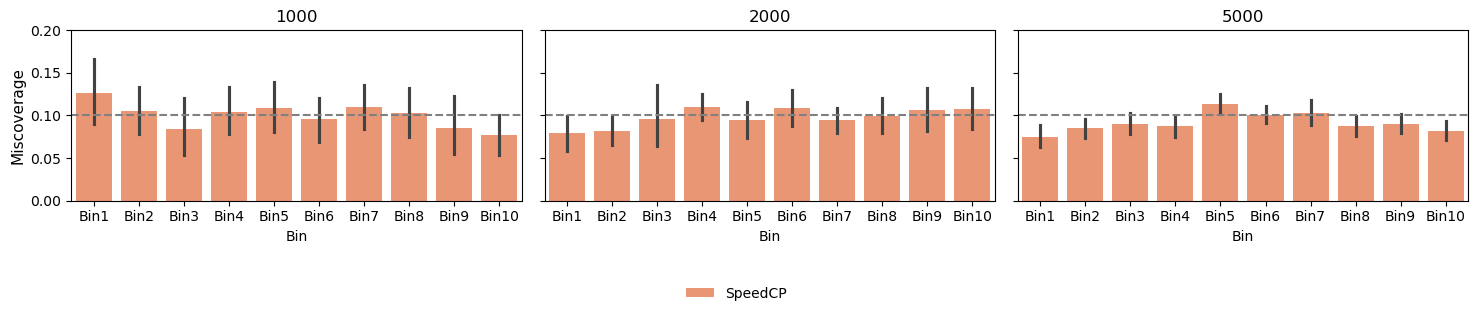

In [11]:
ns = [1000, 2000, 5000]
NBINS = 10

bin_order = [f"Bin{i}" for i in range(1, NBINS + 1)]

cov_bins = coverage_df[coverage_df["shift_type"].str.startswith("Bin")].copy()

fig, axes = plt.subplots(1, len(ns), figsize=(15, 3), sharey=True)

for ax, pred in zip(axes, ns):
    sub = cov_bins[
        (cov_bins["n"] == pred) &
        (cov_bins["predictor"] == "linreg")
    ].copy()

    if sub.empty:
        ax.set_visible(False)
        continue

    sub["shift_type"] = pd.Categorical(
        sub["shift_type"],
        categories=bin_order,
        ordered=True
    )

    sns.barplot(
        data=sub,
        x="shift_type",
        y="coverage",
        hue="method",
        palette=palette,
        ax=ax
    )
    ax.set_ylim(0, 0.2)

    ax.axhline(0.1, color="gray", linestyle="--")

    title_pred = {
        "1000": "n=1000",
        "2000": "n=2000",
        "5000": "n=5000",
    }.get(pred, pred)
    ax.set_title(title_pred, fontsize=12)

    ax.set_xlabel("Bin")
    ax.set_xticklabels(bin_order, rotation=0, fontsize=10)
    ax.tick_params(axis="y", labelsize=10)

    if ax is axes[0]:
        ax.set_ylabel("Miscoverage", fontsize=11)
    else:
        ax.set_ylabel("")

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(labels),
    frameon=False,
    title=None
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()
# plt.savefig(os.path.join(PLOTDIR, "coverage_1x3_predictors_n1000_West.pdf"), dpi=300)

In [12]:
# filter to SpeedCP + linreg + Marginal
marg_speed = coverage_df[
    (coverage_df["method"] == "SpeedCP") &
    (coverage_df["predictor"] == "linreg") &
    (coverage_df["shift_type"] == "Marginal") &
    (coverage_df["n"].isin(ns))
].copy()

speed_summary = (
    marg_speed
    .groupby("n", as_index=False)
    .agg(
        cutoff_mean=("cutoff", "mean"),
        cutoff_sd=("cutoff", "std"),
        time_mean=("time", "mean"),
        time_sd=("time", "std"),
    )
)

print("\n=== SpeedCP (linreg, W_est) ===")
header = ["n", "size mean (sd)", "time mean (sd)"]
print("  ".join(f"{h:>18}" for h in header))

for _, row in speed_summary.iterrows():
    n_val = int(row["n"])
    size_str = f"{row['cutoff_mean']:.3f} ({row['cutoff_sd']:.3f})"
    time_str = f"{row['time_mean']:.3f} ({row['time_sd']:.3f})"
    print("  ".join(f"{c:>18}" for c in [f"n={n_val}", size_str, time_str]))


=== SpeedCP (linreg, W_est) ===
                 n      size mean (sd)      time mean (sd)
            n=1000       1.376 (0.078)      12.363 (4.105)
            n=2000       2.053 (0.116)      23.956 (7.031)
            n=5000       1.030 (0.028)    191.255 (29.362)


## Fine-gridded conditional coverage on the simplex

In [13]:
def ternary_heatmap_all_methods(xy, cover_dict, method_names=None, cmap=plt.cm.RdYlBu, nbins=30):
    if method_names is None:
        method_names = list(cover_dict.keys())

    n_methods = len(method_names)
    n_cols = min(3, n_methods)
    n_rows = int(np.ceil(n_methods / n_cols))

    # Define triangle corners
    triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
    
    # Create triangular grid
    x_vals = np.linspace(0, 1, nbins)
    y_vals = np.linspace(0, np.sqrt(3)/2, nbins)
    Xg, Yg = np.meshgrid(x_vals, y_vals)
    grid_points = np.vstack([Xg.ravel(), Yg.ravel()]).T

    # Mask points outside the triangle
    A = triangle[0]
    B = triangle[1]
    C = triangle[2]
    def in_triangle(p):
        v0 = C - A
        v1 = B - A
        v2 = p - A
        d00 = np.dot(v0, v0)
        d01 = np.dot(v0, v1)
        d11 = np.dot(v1, v1)
        d20 = np.dot(v2, v0)
        d21 = np.dot(v2, v1)
        denom = d00 * d11 - d01 * d01
        v = (d11 * d20 - d01 * d21) / denom
        w = (d00 * d21 - d01 * d20) / denom
        u = 1 - v - w
        return (u >= 0) & (v >= 0) & (w >= 0)

    mask = np.array([in_triangle(p) for p in grid_points])
    triangle_grid = grid_points[mask]

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
    axs = np.array(axs).flatten()
    #norm = Normalize(vmin=0, vmax=1)
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=0.85, vcenter=0.9, vmax=0.97)

    for i, method in enumerate(method_names):
        print(method)
        values = cover_dict[method]
        z_grid = np.full(len(triangle_grid), np.nan)

        radius = 2 / nbins
        for j, center in enumerate(triangle_grid):
            dists = np.linalg.norm(xy - center, axis=1)
            neighbors = values[dists < radius]
            if len(neighbors) > 0:
                z_grid[j] = neighbors.mean()

        ax = axs[i]
        sc = ax.tripcolor(
            triangle_grid[:, 0], triangle_grid[:, 1], z_grid,
            shading='flat', cmap=cmap, norm=norm
        )

        ax.plot(*triangle[[0, 1]].T, color='black')
        ax.plot(*triangle[[1, 2]].T, color='black')
        ax.plot(*triangle[[2, 0]].T, color='black')
        ax.set_title(f"{method}", fontsize=20) 
        ax.set_xlim(0, 1)
        ax.set_ylim(0, np.sqrt(3)/2)
        ax.set_aspect('equal')

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    ax.set_xticks([])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Smoothed Coverage")
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout(rect=[0, 0, 0.9, 1])

In [14]:
methods_to_include = [
    ("SpeedCP",  "speedcp_covers",    "speedcp_cutoffs",    "speedcp_time"),
    ("CondCP",    "condconf_covers",    "condconf_cutoffs",    "condconf_time"),
    ("SplitCP",    "scp_covers",         "scp_cutoffs",         "scp_time"),
    ("PCP",         "pcp_covers",         "pcp_cutoffs",         "pcp_time"),
    ("RLCP",        "rlcp_covers",        "rlcp_cutoffs",        "rlcp_time"),
]

method_names = [m[0] for m in methods_to_include]

W_all = []
covers_list = {method: [] for method in method_names}
cutoffs_list = {method: [] for method in method_names}

for f in files:
    d = np.load(f, allow_pickle=True)

    seed = int(d["seed"])

    predictor = str(d["predictor"])
    if predictor != "nn":
        continue
    n_val     = int(d["n"])        
    W_source  = str(d["W_source"]) 

    W_test = d["W_test"]
    W_all.append(W_test)

    for method_name, cov_key, cutoff_key, time_key in methods_to_include:
        cutoffs = d[cutoff_key]
        covers = d[cov_key]

        # SplitCP cutoffs are scalar; broadcast to length n_test
        if method_name == 'SplitCP':
            cutoffs = np.array([cutoffs] * len(W_test))

        covers_list[method_name].append(covers)
        cutoffs_list[method_name].append(cutoffs)
        runtime = float(d[time_key])

SpeedCP
CondCP
SplitCP
PCP
RLCP


/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_13630/1574301634.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


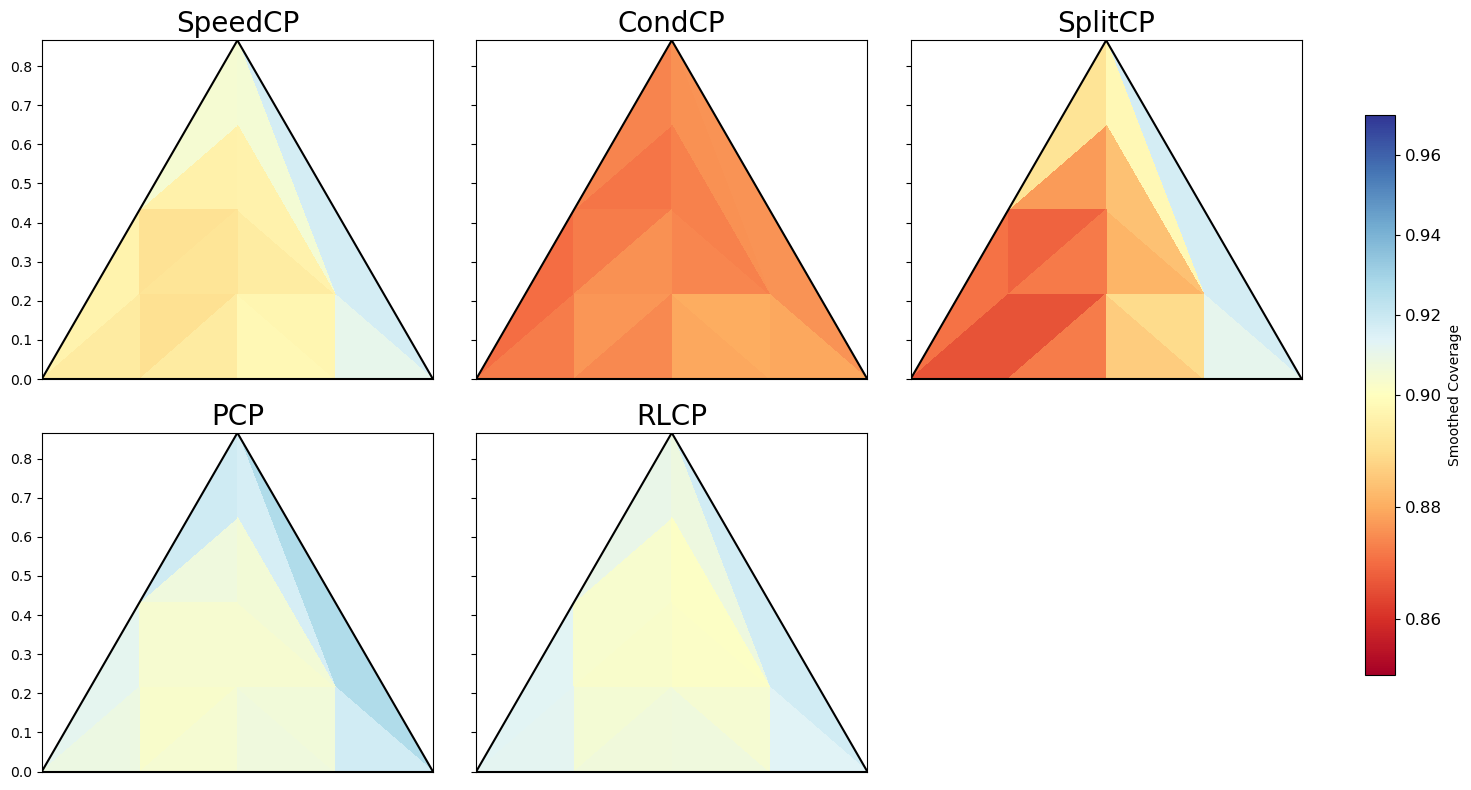

In [15]:
W_all = np.vstack(W_all)
xy = barycentric_to_cartesian(W_all)
cover_dict = {k: np.hstack(v) for k, v in covers_list.items()}
ternary_heatmap_all_methods(xy, cover_dict, nbins=5)
plt.show()